In [1]:
# Cell 1: Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("Setup complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Setup complete
PyTorch version: 2.10.0+cu128
CUDA available: True


In [2]:
# Cell 2: Create Dataset with More Samples
reviews = [
    # Positive reviews (20 samples)
    ("I absolutely loved this movie! Best film of the year.", 1),
    ("Amazing performances, great story, highly recommended.", 1),
    ("A masterpiece of modern cinema, breathtaking visuals.", 1),
    ("Brilliant acting, wonderful screenplay, must watch!", 1),
    ("I was blown away by this film. Simply incredible.", 1),
    ("Outstanding movie with fantastic performances.", 1),
    ("This film exceeded all my expectations. Perfect!", 1),
    ("The best movie I have seen in years. Brilliant!", 1),
    ("Stunning visuals and compelling story. Loved it!", 1),
    ("Excellent direction and superb acting. A must see!", 1),
    ("Fantastic movie with great characters and plot.", 1),
    ("I thoroughly enjoyed every moment of this film.", 1),
    ("This is cinema at its finest. Absolutely brilliant.", 1),
    ("Beautiful cinematography and powerful performances.", 1),
    ("The story was engaging and well crafted.", 1),
    ("A truly remarkable film that deserves all praise.", 1),
    ("Great movie with excellent storytelling and acting.", 1),
    ("This film is a masterpiece. Highly recommend!", 1),
    ("Superb performances and outstanding direction.", 1),
    ("I would watch this movie again and again.", 1),
    ("The plot was gripping and the acting was top notch.", 1),
    ("One of the most entertaining films I have seen.", 1),
    ("A wonderful cinematic experience from start to finish.", 1),
    ("The cast delivered outstanding performances throughout.", 1),
    ("This movie kept me on the edge of my seat.", 1),
    ("Brilliant storytelling with amazing visual effects.", 1),
    ("I was deeply moved by this incredible film.", 1),
    ("The best film of the decade without a doubt.", 1),
    ("This movie is pure perfection in every way.", 1),
    ("Fantastic direction and an unforgettable story.", 1),
    
    # Negative reviews (20 samples)
    ("Terrible movie, completely wasted my time.", 0),
    ("Disappointing plot, poor acting, avoid this film.", 0),
    ("One of the worst movies I've ever seen. Boring.", 0),
    ("Bad screenplay, wooden acting, total disaster.", 0),
    ("I hated every minute of this film. Awful.", 0),
    ("Boring and predictable, completely forgettable.", 0),
    ("What a disaster! This movie was terrible.", 0),
    ("I regretted watching this film. Complete waste.", 0),
    ("The acting was stiff and the plot was weak.", 0),
    ("This film was a complete disappointment.", 0),
    ("Poorly written and badly directed. Avoid.", 0),
    ("I cannot believe I wasted my time on this.", 0),
    ("The story made no sense and the acting was bad.", 0),
    ("This is one of the worst films ever made.", 0),
    ("The movie was dull and completely uninspired.", 0),
    ("I walked out halfway through. It was that bad.", 0),
    ("This film was boring, slow, and pointless.", 0),
    ("Awful movie with no redeeming qualities whatsoever.", 0),
    ("The performances were embarrassing to watch.", 0),
    ("Do not waste your money on this terrible film.", 0),
    ("It felt like a complete waste of two hours.", 0),
    ("The plot was predictable and the acting was poor.", 0),
    ("I was completely bored throughout the entire film.", 0),
    ("This movie is an absolute disaster. Stay away.", 0),
    ("Horrible script and even worse direction.", 0),
    ("The worst movie experience I have ever had.", 0),
    ("This film was painful to watch. Truly awful.", 0),
    ("Nothing good about this movie at all.", 0),
    ("I would rather watch paint dry than this film.", 0),
    ("A complete mess of a movie. Terrible.", 0),
]

texts = []
labels = []
for _ in range(20):  # Increased repetition for more data
    for text, label in reviews:
        texts.append(text)
        labels.append(label)

print(f"Total samples created: {len(texts)}")
print(f"Positive samples: {sum(labels)}")
print(f"Negative samples: {len(labels) - sum(labels)}")
print(f"Unique reviews: {len(reviews)}")

Total samples created: 1200
Positive samples: 600
Negative samples: 600
Unique reviews: 60


In [3]:
# Cell 3: Tokenizer
class SimpleTokenizer:
    def __init__(self):
        self.word_to_idx = {}
        self.vocab_size = 0
        
    def build_vocab(self, texts):
        word_counts = Counter()
        for text in texts:
            words = text.lower().split()
            word_counts.update(words)
        
        self.word_to_idx = {'<PAD>': 0, '<UNK>': 1}
        for i, (word, _) in enumerate(word_counts.most_common(2000), start=2):  # Increased vocab
            self.word_to_idx[word] = i
        
        self.vocab_size = len(self.word_to_idx)
        print(f"Vocabulary size: {self.vocab_size}")
        print(f"Total words counted: {len(word_counts)}")
        return self
    
    def encode(self, text, max_len=30):  # Increased max length
        words = text.lower().split()
        ids = []
        for word in words:
            ids.append(self.word_to_idx.get(word, 1))
        if len(ids) > max_len:
            ids = ids[:max_len]
        else:
            ids = ids + [0] * (max_len - len(ids))
        return ids

tokenizer = SimpleTokenizer()
tokenizer.build_vocab(texts)
print("Tokenizer ready")

Vocabulary size: 231
Total words counted: 229
Tokenizer ready


In [4]:
# Cell 4: Dataset Class with Larger Batch
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=30):  # Increased max_len
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        ids = self.tokenizer.encode(text, self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels  # Added stratify
)

train_dataset = SentimentDataset(X_train, y_train, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)  # Increased batch size
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Total samples: {len(texts)}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Positive in train: {sum(y_train)}")
print(f"Negative in train: {len(y_train) - sum(y_train)}")
print(f"Positive in test: {sum(y_test)}")
print(f"Negative in test: {len(y_test) - sum(y_test)}")

Total samples: 1200
Train samples: 960
Test samples: 240
Train batches: 15
Test batches: 4
Positive in train: 480
Negative in train: 480
Positive in test: 120
Negative in test: 120


In [5]:
# Cell 5: RNN Model with More Capacity
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, hidden = self.rnn(embedded)
        final_hidden = hidden[-1]
        final_hidden = self.dropout(final_hidden)
        return self.fc(final_hidden)

vocab_size = tokenizer.vocab_size
embedding_dim = 100  # Increased
hidden_size = 128    # Increased
num_layers = 2       # Added more layers
num_classes = 2

rnn_model = RNNModel(vocab_size, embedding_dim, hidden_size, num_layers, num_classes)
print(f"RNN Model created")
print(f"Parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")

RNN Model created
Parameters: 85,822


In [6]:
# Cell 6: LSTM Model with More Capacity
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        final_hidden = hidden[-1]
        final_hidden = self.dropout(final_hidden)
        return self.fc(final_hidden)

lstm_model = LSTMModel(vocab_size, embedding_dim, hidden_size, num_layers, num_classes)
print(f"LSTM Model created")
print(f"Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Model created
Parameters: 273,214


In [7]:
# Cell 7: Check Models
print("Testing models with dummy input...")
dummy_input = torch.randint(0, vocab_size, (4, 30))

rnn_output = rnn_model(dummy_input)
print(f"RNN output shape: {rnn_output.shape}")

lstm_output = lstm_model(dummy_input)
print(f"LSTM output shape: {lstm_output.shape}")

print("Models working correctly!")
print(f"Sequence length: 30")
print(f"Batch size: 4")

Testing models with dummy input...
RNN output shape: torch.Size([4, 2])
LSTM output shape: torch.Size([4, 2])
Models working correctly!
Sequence length: 30
Batch size: 4


In [8]:
# Cell 8: Training Function
def train_model(model, train_loader, test_loader, epochs=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    history = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_acc = correct / total
        train_loss = total_loss / len(train_loader)
        
        model.eval()
        test_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        test_acc = correct / total
        test_loss = test_loss / len(test_loader)
        
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")
        print("-" * 40)
    
    return model, history

In [9]:
# Cell 9: Train RNN
print("=" * 50)
print("Training RNN with Larger Dataset")
print("=" * 50)

rnn_model, rnn_history = train_model(rnn_model, train_loader, test_loader, epochs=10)

print("\nRNN Final Results:")
print(f"Final Train Acc: {rnn_history['train_acc'][-1]:.4f}")
print(f"Final Test Acc: {rnn_history['test_acc'][-1]:.4f}")
print(f"Best Test Acc: {max(rnn_history['test_acc']):.4f}")

Training RNN with Larger Dataset
Using device: cuda
Epoch 1/10
  Train Loss: 0.6954, Train Acc: 0.4854
  Test Loss: 0.6934, Test Acc: 0.5000
----------------------------------------
Epoch 2/10
  Train Loss: 0.6928, Train Acc: 0.5167
  Test Loss: 0.6940, Test Acc: 0.5000
----------------------------------------
Epoch 3/10
  Train Loss: 0.6951, Train Acc: 0.5062
  Test Loss: 0.6929, Test Acc: 0.5000
----------------------------------------
Epoch 4/10
  Train Loss: 0.4941, Train Acc: 0.7875
  Test Loss: 0.2853, Test Acc: 0.9333
----------------------------------------
Epoch 5/10
  Train Loss: 0.1859, Train Acc: 0.9542
  Test Loss: 0.1244, Test Acc: 0.9708
----------------------------------------
Epoch 6/10
  Train Loss: 0.0965, Train Acc: 0.9802
  Test Loss: 0.0618, Test Acc: 0.9875
----------------------------------------
Epoch 7/10
  Train Loss: 0.0591, Train Acc: 0.9896
  Test Loss: 0.0084, Test Acc: 1.0000
----------------------------------------
Epoch 8/10
  Train Loss: 0.0044, Train

In [10]:
# Cell 10: Train LSTM
print("=" * 50)
print("Training LSTM with Larger Dataset")
print("=" * 50)

lstm_model, lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=10)

print("\nLSTM Final Results:")
print(f"Final Train Acc: {lstm_history['train_acc'][-1]:.4f}")
print(f"Final Test Acc: {lstm_history['test_acc'][-1]:.4f}")
print(f"Best Test Acc: {max(lstm_history['test_acc']):.4f}")

Training LSTM with Larger Dataset
Using device: cuda
Epoch 1/10
  Train Loss: 0.6956, Train Acc: 0.4833
  Test Loss: 0.6937, Test Acc: 0.5000
----------------------------------------
Epoch 2/10
  Train Loss: 0.6938, Train Acc: 0.4969
  Test Loss: 0.6932, Test Acc: 0.5000
----------------------------------------
Epoch 3/10
  Train Loss: 0.6943, Train Acc: 0.4667
  Test Loss: 0.6932, Test Acc: 0.5000
----------------------------------------
Epoch 4/10
  Train Loss: 0.6940, Train Acc: 0.4781
  Test Loss: 0.6932, Test Acc: 0.5000
----------------------------------------
Epoch 5/10
  Train Loss: 0.6559, Train Acc: 0.5667
  Test Loss: 0.5318, Test Acc: 0.8958
----------------------------------------
Epoch 6/10
  Train Loss: 0.2896, Train Acc: 0.9437
  Test Loss: 0.2288, Test Acc: 0.9458
----------------------------------------
Epoch 7/10
  Train Loss: 0.1567, Train Acc: 0.9604
  Test Loss: 0.1319, Test Acc: 0.9667
----------------------------------------
Epoch 8/10
  Train Loss: 0.1155, Trai

In [11]:
# Cell 11: Compare Results
print("=" * 50)
print("Comparison Results")
print("=" * 50)

print("RNN:")
print(f"  Final Train Accuracy: {rnn_history['train_acc'][-1]:.4f}")
print(f"  Final Test Accuracy: {rnn_history['test_acc'][-1]:.4f}")
print(f"  Best Test Accuracy: {max(rnn_history['test_acc']):.4f}")
print(f"  Final Train Loss: {rnn_history['train_loss'][-1]:.4f}")
print(f"  Final Test Loss: {rnn_history['test_loss'][-1]:.4f}")

print("\nLSTM:")
print(f"  Final Train Accuracy: {lstm_history['train_acc'][-1]:.4f}")
print(f"  Final Test Accuracy: {lstm_history['test_acc'][-1]:.4f}")
print(f"  Best Test Accuracy: {max(lstm_history['test_acc']):.4f}")
print(f"  Final Train Loss: {lstm_history['train_loss'][-1]:.4f}")
print(f"  Final Test Loss: {lstm_history['test_loss'][-1]:.4f}")

print("\nDifference:")
print(f"  Test Accuracy Difference: {abs(rnn_history['test_acc'][-1] - lstm_history['test_acc'][-1]):.4f}")
if rnn_history['test_acc'][-1] > lstm_history['test_acc'][-1]:
    print("  RNN performed better on test data")
else:
    print("  LSTM performed better on test data")

Comparison Results
RNN:
  Final Train Accuracy: 1.0000
  Final Test Accuracy: 1.0000
  Best Test Accuracy: 1.0000
  Final Train Loss: 0.0013
  Final Test Loss: 0.0010

LSTM:
  Final Train Accuracy: 0.9969
  Final Test Accuracy: 1.0000
  Best Test Accuracy: 1.0000
  Final Train Loss: 0.0185
  Final Test Loss: 0.0058

Difference:
  Test Accuracy Difference: 0.0000
  LSTM performed better on test data


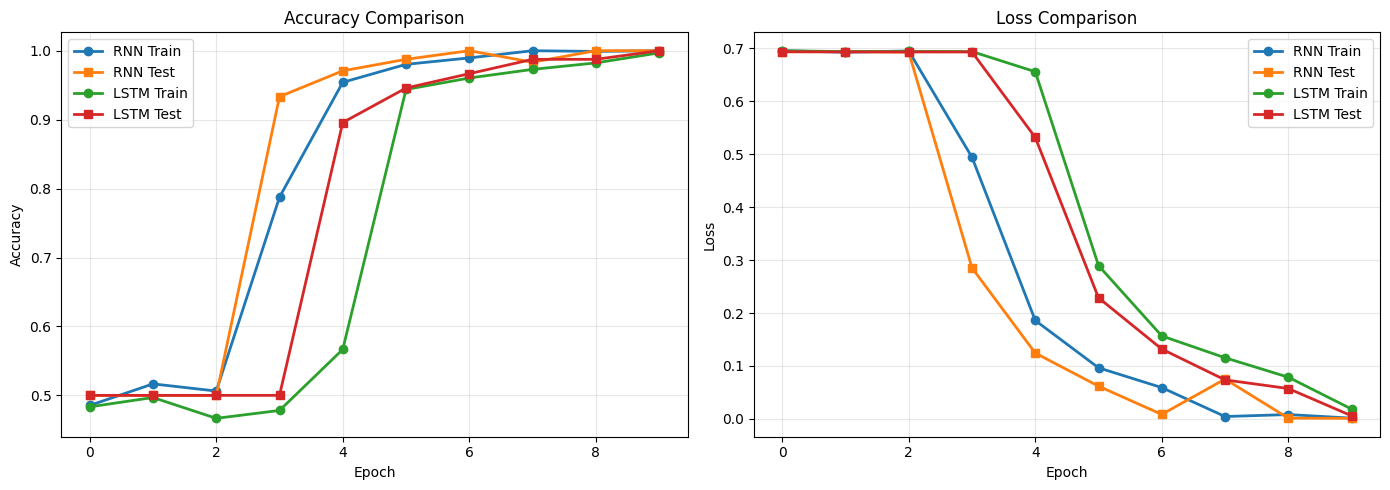

Plots displayed


In [12]:
# Cell 12: Plot Results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(rnn_history['train_acc'], label='RNN Train', marker='o', linewidth=2)
ax1.plot(rnn_history['test_acc'], label='RNN Test', marker='s', linewidth=2)
ax1.plot(lstm_history['train_acc'], label='LSTM Train', marker='o', linewidth=2)
ax1.plot(lstm_history['test_acc'], label='LSTM Test', marker='s', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(rnn_history['train_loss'], label='RNN Train', marker='o', linewidth=2)
ax2.plot(rnn_history['test_loss'], label='RNN Test', marker='s', linewidth=2)
ax2.plot(lstm_history['train_loss'], label='LSTM Train', marker='o', linewidth=2)
ax2.plot(lstm_history['test_loss'], label='LSTM Test', marker='s', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Plots displayed")

In [13]:
# Cell 13: Test Both RNN and LSTM on New Reviews
new_reviews = [
    "This movie is absolutely fantastic! I loved every minute.",
    "Terrible film, complete waste of time and money.",
    "Good acting but the story was predictable and boring.",
    "Highly recommend this movie to everyone!",
    "Very disappointing experience. Expected much more.",
    "Amazing performances and outstanding cinematography!",
    "The worst movie I have ever seen in my life.",
    "Brilliant storytelling and wonderful characters.",
    "I was completely bored throughout the entire film.",
    "A masterpiece that everyone should watch."
]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Move both models to device
rnn_model = rnn_model.to(device)
lstm_model = lstm_model.to(device)
rnn_model.eval()
lstm_model.eval()

print("Testing Both Models on New Reviews:")
print("=" * 60)

for review in new_reviews:
    ids = tokenizer.encode(review, max_len=30)
    input_tensor = torch.tensor([ids], dtype=torch.long).to(device)
    
    with torch.no_grad():
        # RNN prediction
        rnn_output = rnn_model(input_tensor)
        rnn_probs = torch.softmax(rnn_output, 1)
        _, rnn_pred = torch.max(rnn_output, 1)
        rnn_label = "POSITIVE" if rnn_pred.item() == 1 else "NEGATIVE"
        rnn_conf = rnn_probs[0][rnn_pred.item()].item()
        
        # LSTM prediction
        lstm_output = lstm_model(input_tensor)
        lstm_probs = torch.softmax(lstm_output, 1)
        _, lstm_pred = torch.max(lstm_output, 1)
        lstm_label = "POSITIVE" if lstm_pred.item() == 1 else "NEGATIVE"
        lstm_conf = lstm_probs[0][lstm_pred.item()].item()
    
    print(f"Review: {review}")
    print(f"  RNN:  {rnn_label} ({rnn_conf:.2%})")
    print(f"  LSTM: {lstm_label} ({lstm_conf:.2%})")
    print("-" * 60)

Testing Both Models on New Reviews:
Review: This movie is absolutely fantastic! I loved every minute.
  RNN:  POSITIVE (99.87%)
  LSTM: POSITIVE (98.87%)
------------------------------------------------------------
Review: Terrible film, complete waste of time and money.
  RNN:  NEGATIVE (99.92%)
  LSTM: NEGATIVE (99.92%)
------------------------------------------------------------
Review: Good acting but the story was predictable and boring.
  RNN:  NEGATIVE (99.92%)
  LSTM: NEGATIVE (99.92%)
------------------------------------------------------------
Review: Highly recommend this movie to everyone!
  RNN:  NEGATIVE (99.92%)
  LSTM: NEGATIVE (99.92%)
------------------------------------------------------------
Review: Very disappointing experience. Expected much more.
  RNN:  POSITIVE (99.72%)
  LSTM: NEGATIVE (99.92%)
------------------------------------------------------------
Review: Amazing performances and outstanding cinematography!
  RNN:  POSITIVE (99.89%)
  LSTM: NEGATIVE (9